# PyDMA → PyBaMM: parameter integration

Starting from a fitted `DMAResult` and the cell parameters documented
in **Frank et al. (2025), Table III**
([DOI 10.1149/1945-7111/adc03c](https://doi.org/10.1149/1945-7111/adc03c)),
this notebook builds a PyBaMM `ParameterValues` for a
Molicel INR21700-P45B and verifies the result by simulating a C/500
charge in DFN and comparing it back to the measured pOCV that PyDMA
was fit on.

Everything that touches PyDMA outputs goes through the public pydma
API: `derive_balancing_from_result`, `CellGeometry`,
`ElectrodeBalancing.pybamm_overrides`, and
`BlendElectrode.get_blend_curve`.

### Non-goals

This notebook intentionally does **not**:

- run a multi-CU aging-study loop,
- re-smooth or resample the DVA onto an auxiliary grid,
- derive a per-phase Gr / Si capacity split (Frank Table III does not
  report per-phase active-material volume fractions),
- depend on any proprietary parameter set.

Every material-property value comes from Frank (2025) Table III,
centralised in `parameter_data/frank2025_p45b_table_iii.json`. The
base parameter set `Chen2020` is loaded **only** as the
public PyBaMM fallback for slots Frank does not document
(electrolyte transport, entropic coefficients, exchange-current
density).


## 1. Setup


In [1]:
import inspect
import sys
from pathlib import Path

# Prefer the in-repo PyDMA src/ when this notebook runs from a checkout.
repo_src = None
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    candidate = base / "src" / "pydma"
    if candidate.is_dir():
        repo_src = base / "src"
        break
if repo_src is not None and str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.5,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

import pybamm
import pydma
from pydma import (
    DMAAnalyzer, DMAConfig, ElectrodeOCP, BlendElectrode,
    load_ocp, generate_si_curve, calculate_dva,
    CellGeometry, derive_balancing_from_result,
)

# Notebook-local paths.
HERE       = Path.cwd().resolve()
while HERE.name != "notebooks" and HERE.parent != HERE:
    # If we were launched from the repo root, descend.
    if (HERE / "notebooks").is_dir():
        HERE = HERE / "notebooks"
        break
    HERE = HERE.parent if HERE.name != "pydma" else HERE / "notebooks"
    if HERE.name == "notebooks":
        break
if not (HERE / "TestData").is_dir():
    # Fallback: assume notebook is run from notebooks/ directly.
    HERE = Path.cwd().resolve()

print(f"PyDMA  {pydma.__version__}  ({Path(pydma.__file__).resolve()})")
print(f"PyBaMM {pybamm.__version__}")
print(f"notebooks/ resolved to: {HERE}")


PyDMA  1.0.1  (C:\Users\rehm\Desktop\pydma\src\pydma\__init__.py)
PyBaMM 0.0.0
notebooks/ resolved to: C:\Users\rehm\Desktop\pydma\notebooks


## 2. Run a PyDMA fit on the P45B BoL pOCV

Same input data as `getting_started.ipynb`: Si-Gr half-cell
(P45B lithiation), graphite half-cell (Rehm 2026), NCA half-cell
(P45b GITT extracted pOCP), and the BoL full-cell pOCV
(`FR23_pOCV_CH_entry01.csv`). The notebook is self-contained —
you do **not** need to have run `getting_started.ipynb` first.

`gamma_anode_blend2_init=0.25` is a PyDMA optimiser seed, **not** a
Frank-paper constant. PyDMA fits the actual blend fraction
(`fitted_params.gamma_blend2_an`) from the BoL pOCV.


In [2]:
in_data = HERE / "TestData" / "InputData"

blend_df    = pd.read_csv(in_data / "SiGr_blend_anode" / "P45B_Anode_Lithiation_0C03.csv")
graphite_df = pd.read_csv(in_data / "Graphite"          / "Gr_Lithiation_Rehm2026.csv")

cathode = load_ocp(
    in_data / "NCA" / "GITT_P45b_Cat_NCA_JN_VS_Coin_1_GITT__Extracted_Continuous_pOCP.csv",
    electrode_type="cathode", smooth=False,
)

si_result = generate_si_curve(
    graphite_data=(graphite_df["voltage"].values, graphite_df["normalizedCapacity"].values),
    blend_data   =(blend_df   ["voltage"].values, blend_df   ["normalizedCapacity"].values),
    gamma_si=0.245,             # optimiser seed for the blend extraction
    monotone_filter=True,
)
graphite = ElectrodeOCP(soc=si_result.graphite_capacity,   voltage=si_result.graphite_voltage, name="Graphite")
silicon  = ElectrodeOCP(soc=si_result.normalized_capacity, voltage=si_result.voltage,         name="Silicon")
si_gr_anode = BlendElectrode(blend1=graphite, blend2=silicon, name="Si-Gr Anode (P45B)")

pocv_df = pd.read_csv(HERE / "TestData" / "FR23_pOCV_CH_entry01.csv")
cap_meas  = pocv_df["Ah_Step"].values
volt_meas = pocv_df["U"].values
mask = ~(np.isnan(cap_meas) | np.isnan(volt_meas))
cap_meas, volt_meas = cap_meas[mask], volt_meas[mask]
Q_BoL_Ah = float(cap_meas.max() - cap_meas.min())

config = DMAConfig(
    speed_preset="medium", direction="charge",
    use_anode_blend=True,
    gamma_anode_blend2_init=0.25,
    gamma_anode_blend2_upper=0.30,
    req_accepted=1, max_tries_overall=5,
)
analyzer = DMAAnalyzer(config)
analyzer.set_anode(si_gr_anode)
analyzer.set_cathode(cathode)
analyzer.set_reference_capacity(Q_BoL_Ah)
result = analyzer.analyze(measured_capacity=cap_meas, measured_voltage=volt_meas)

v_min_meas = float(volt_meas.min())
v_max_meas = float(volt_meas.max())
pydma_rmse_mV = float(result.rmse_full_range * 1000)
gamma_si = float(result.fitted_params.gamma_blend2_an)

print(f"Q_BoL  = {Q_BoL_Ah:.4f} A.h     V in [{v_min_meas:.3f}, {v_max_meas:.3f}] V")
print(f"PyDMA  RMSE         = {pydma_rmse_mV:.2f} mV")
print(f"PyDMA  fitted gamma_Si = {gamma_si:.4f}")


Run 1: RMSE=5.0 mV (accepted) [accepted=1, rejected=0]
Q_BoL  = 4.4707 A.h     V in [2.502, 4.200] V
PyDMA  RMSE         = 5.01 mV
PyDMA  fitted gamma_Si = 0.2342


## 3. Cell geometry from Frank (2025) Table III

Geometry values are loaded inline below from Frank's Table III. The
full set of Frank constants — including these — lives in
`parameter_data/frank2025_p45b_table_iii.json`; we read the geometry
fields from there so the JSON file is the **single source of truth**
for every Frank value used in this notebook.


In [3]:
FRANK_JSON = HERE / "parameter_data" / "frank2025_p45b_table_iii.json"
with FRANK_JSON.open() as f:
    frank_doc = json.load(f)
frank = {k: v["value"] for k, v in frank_doc["parameters"].items()}

eps_s_neg = frank["Negative electrode active material volume fraction"]   # 0.754
eps_s_pos = frank["Positive electrode active material volume fraction"]   # 0.723
L_neg     = frank["Negative electrode thickness [m]"]                     # 5.0e-5
L_pos     = frank["Positive electrode thickness [m]"]                     # 4.2e-5

# Active coated area (both coated sides of the jelly-roll):
#   cathode length 129.4 cm x height 6.3 cm x 2 sides = 0.163 m^2
A_act = (
    frank["Electrode width [m]"]
    * frank["Electrode height [m]"]
    * frank["Number of electrodes connected in parallel to make a cell"]
)

geom = CellGeometry(
    eps_s_neg=eps_s_neg,
    eps_s_pos=eps_s_pos,
    L_neg=L_neg,
    L_pos=L_pos,
    A=A_act,                # both-sides total - see note below
    Q_BoL_Ah=Q_BoL_Ah,
)

print(f"Frank source: {frank_doc['_metadata']['source']}")
print(f"          doi: {frank_doc['_metadata']['doi']}")
print()
print(f"eps_s_neg / eps_s_pos = {eps_s_neg:.3f} / {eps_s_pos:.3f}")
print(f"L_neg     / L_pos     = {L_neg*1e6:.1f} um / {L_pos*1e6:.1f} um")
print(f"A_act                 = {A_act:.4f} m^2  (= width x height x N_parallel, both sides)")
print(f"Q_BoL                 = {Q_BoL_Ah:.4f} A.h (from measured BoL pOCV)")


Frank source: Frank et al. (2025), Table III
          doi: 10.1149/1945-7111/adc03c

eps_s_neg / eps_s_pos = 0.754 / 0.723
L_neg     / L_pos     = 50.0 um / 42.0 um
A_act                 = 0.1630 m^2  (= width x height x N_parallel, both sides)
Q_BoL                 = 4.4707 A.h (from measured BoL pOCV)


**Area-convention note.** PyDMA's `CellGeometry.A` docstring says
"single side", but the math in `derive_balancing` is
convention-agnostic as long as `A` and `Q_BoL` describe the same
physical electrode. Using Frank's `A_act = 0.163 m^2` (both sides) is
the only choice that lets the derived `c_max` be directly comparable
to Frank Table III's `c_s,max,neg = 26911 mol/m^3` /
`c_s,max,pos = 33913 mol/m^3`. PyBaMM is made consistent with this in
§6 below by setting
`Number of electrodes connected in parallel to make a cell = 2`, so
PyBaMM's effective area `(Electrode width) x (Electrode height) x
(N_parallel) = 0.163 m^2` matches `CellGeometry.A`.

**Source-of-error sanity note.** The previous
`getting_started.ipynb` cell 28 carried `eps_s_neg = 0.775`,
`eps_s_pos = 0.719`. Those values are **not** from Frank Table III
(which reports 75.4 % and 72.3 %). This notebook uses the Table III
values directly.


## 4. Derive c_max and c_init via PyDMA

`derive_balancing_from_result` voltage-anchors PyDMA's fitted
stoichiometry windows at the measured pOCV cut-offs, then applies the
standard charge balance
`Q_BoL * 3600 / F = eps_s * L * A * c_max * util`
to back out `c_max` for each electrode. The single-method call below
is the entire bridge.


In [4]:
bal = derive_balancing_from_result(
    result, geom, v_min=v_min_meas, v_max=v_max_meas,
)

print(f"c_max_neg = {bal.c_max_neg:>9.0f} mol/m^3   (Frank Tab. III: 26911 mol/m^3)")
print(f"c_max_pos = {bal.c_max_pos:>9.0f} mol/m^3   (Frank Tab. III: 33913 mol/m^3)")
print(f"delta_neg = {(bal.c_max_neg - 26911) / 26911 * 100:+.2f} %")
print(f"delta_pos = {(bal.c_max_pos - 33913) / 33913 * 100:+.2f} %")
print()
print(f"sto_window_neg = [{bal.sto_window_neg[0]:.4f}, {bal.sto_window_neg[1]:.4f}]")
print(f"sto_window_pos = [{bal.sto_window_pos[0]:.4f}, {bal.sto_window_pos[1]:.4f}]  (PyBaMM x_p)")
print(f"util_neg / util_pos = {bal.util_neg:.4f} / {bal.util_pos:.4f}")
print(f"Q_n / Q_p / Q_Li    = {bal.Q_n:.4f} / {bal.Q_p:.4f} / {bal.Q_Li:.4f} A.h")


c_max_neg =     28070 mol/m^3   (Frank Tab. III: 26911 mol/m^3)
c_max_pos =     37656 mol/m^3   (Frank Tab. III: 33913 mol/m^3)
delta_neg = +4.31 %
delta_pos = +11.04 %

sto_window_neg = [0.0005, 0.9672]
sto_window_pos = [0.9127, 0.0179]  (PyBaMM x_p)
util_neg / util_pos = 0.9668 / 0.8947
Q_n / Q_p / Q_Li    = 4.6244 / 4.9967 / 4.5625 A.h


## 5. Per-phase Gr / Si split — out of scope here

The whole-anode `c_max_neg` derived in §4 is what a
single-particle DFN with one blended OCP needs — which is the
modelling choice in this notebook (Frank's 1D-DFN also uses a single
blended anode OCP).

For a two-particle composite DFN you would need per-phase Gr and Si
`c_max` values. PyDMA exposes the helper
`DMAResult.voltage_anchored_blend_phase_export_from_ocp_model(...)`
for that, but it requires per-phase active-material volume fractions
(Gr vs Si shares of `eps_s_neg`) which **Frank Table III does not
report**. The per-phase split is therefore deliberately out of scope
here.


## 6. Build the PyBaMM `ParameterValues`

We use the publicly available `Chen2020` set as a base,
then overlay (1) all Frank Table III constants from the JSON data
file, (2) the PyDMA-derived `c_max` / `c_init`, and (3) the
PyDMA-derived OCPs.


### 6a. Provenance of every key the simulation will see

| PyBaMM key | Value | Source |
|---|---|---|
| `Negative electrode active material volume fraction` | 0.754 | Frank 2025 Tab. III |
| `Positive electrode active material volume fraction` | 0.723 | Frank 2025 Tab. III |
| `Negative electrode porosity` | 0.196 | Frank 2025 Tab. III |
| `Positive electrode porosity` | 0.227 | Frank 2025 Tab. III |
| `Separator porosity` | 0.40 | Frank 2025 Tab. III |
| `Negative electrode thickness [m]` | 5.0e-5 | Frank 2025 Tab. III |
| `Positive electrode thickness [m]` | 4.2e-5 | Frank 2025 Tab. III |
| `Separator thickness [m]` | 1.4e-5 | Frank 2025 Tab. III |
| `Electrode width [m]` | 1.294 | Frank Tab. III (cathode length) |
| `Electrode height [m]` | 0.063 | Frank Tab. III (cathode height) |
| `Number of electrodes connected in parallel to make a cell` | 2 | Frank Tab. III (both sides of jelly-roll → `A_act = 0.163 m^2`) |
| `Negative particle radius [m]` | 5.11e-6 | Frank Tab. III (D50) |
| `Positive particle radius [m]` | 7.54e-6 | Frank Tab. III (D50) |
| `Negative particle diffusivity [m2.s-1]` | 1.5e-13 | Frank Tab. III |
| `Positive particle diffusivity [m2.s-1]` | 1.6e-13 | Frank Tab. III |
| `Negative electrode conductivity [S.m-1]` | 38.7 | Frank Tab. III |
| `Positive electrode conductivity [S.m-1]` | 17.3 | Frank Tab. III |
| `Negative electrode Bruggeman coefficient (electrolyte)` | 1.7 | Frank Tab. III (α = 0.7 → b = 1 + α) |
| `Positive electrode Bruggeman coefficient (electrolyte)` | 1.5 | Frank Tab. III (α = 0.5) |
| `Separator Bruggeman coefficient (electrolyte)` | 1.5 | Frank Tab. III (α = 0.5) |
| `Negative current collector thickness [m]` | 1.0e-5 | Frank Tab. III (Cu) |
| `Positive current collector thickness [m]` | 1.4e-5 | Frank Tab. III (Al) |
| `Negative current collector conductivity [S.m-1]` | 5.95e7 | Frank Tab. III |
| `Positive current collector conductivity [S.m-1]` | 3.77e7 | Frank Tab. III |
| `Maximum concentration in negative electrode [mol.m-3]` | derived | **PyDMA + Frank geometry (§4)** |
| `Maximum concentration in positive electrode [mol.m-3]` | derived | **PyDMA + Frank geometry (§4)** |
| `Initial concentration in negative electrode [mol.m-3]` | derived | **PyDMA + Frank geometry (§4)** |
| `Initial concentration in positive electrode [mol.m-3]` | derived | **PyDMA + Frank geometry (§4)** |
| `Negative electrode OCP [V]` | functional (CSV) | **PyDMA blend at fitted γ_Si** |
| `Positive electrode OCP [V]` | functional (CSV) | **Measured half-cell, flipped to PyBaMM `x_p`** |
| `Initial electrolyte concentration [mol.m-3]` | — | Chen2020 (fallback) |
| `Electrolyte diffusivity [m2.s-1]` | — | Chen2020 (fallback) |
| `Electrolyte transference number` | — | Chen2020 (fallback) |
| `Negative/Positive electrode exchange-current density [A.m-2]` | — | Chen2020 (fallback; Frank Fig. 1e is `i_0(x, T)` — not a scalar) |
| `Negative/Positive electrode OCP entropic change [V.K-1]` | — | Chen2020 (fallback; Frank Fig. 1d is a function of `x`) |

`Chen2020` is loaded **only** as a public PyBaMM lithium-ion
fallback base. Its native chemistry is NMC811 / graphite (the
LGM50 cell), but that doesn't matter here — every P45B-specific
parameter Frank Table III documents is overridden below, and the
OCPs are replaced with PyDMA-derived curves. Keys remaining at
Chen2020 defaults (electrolyte transport, kinetics, entropic
coefficients) are flagged as *fallback* in §6d.


### 6b. Load Frank constants from the JSON data file and apply


In [5]:
# `frank` was already built in §3 from frank2025_p45b_table_iii.json.
print(f"Loaded {len(frank)} Frank-Table-III parameters from {FRANK_JSON.name}")
print(f"  source: {frank_doc['_metadata']['source']}")
print(f"  doi:    {frank_doc['_metadata']['doi']}")

pv = pybamm.ParameterValues("Chen2020")
pv.update(frank, check_already_exists=False)

# PyDMA-derived c_max / c_init at SoC = 0 (live - depends on this PyDMA fit).
pv.update(bal.pybamm_overrides(soc=0.0))

print("\nApplied overrides:")
for k in [
    "Negative electrode active material volume fraction",
    "Positive electrode active material volume fraction",
    "Negative electrode thickness [m]",
    "Positive electrode thickness [m]",
    "Electrode width [m]",
    "Electrode height [m]",
    "Number of electrodes connected in parallel to make a cell",
    "Maximum concentration in negative electrode [mol.m-3]",
    "Maximum concentration in positive electrode [mol.m-3]",
    "Initial concentration in negative electrode [mol.m-3]",
    "Initial concentration in positive electrode [mol.m-3]",
]:
    print(f"  {k}: {pv[k]}")


Loaded 24 Frank-Table-III parameters from frank2025_p45b_table_iii.json
  source: Frank et al. (2025), Table III
  doi:    10.1149/1945-7111/adc03c

Applied overrides:
  Negative electrode active material volume fraction: 0.754
  Positive electrode active material volume fraction: 0.723
  Negative electrode thickness [m]: 5e-05
  Positive electrode thickness [m]: 4.2e-05
  Electrode width [m]: 1.294
  Electrode height [m]: 0.063
  Number of electrodes connected in parallel to make a cell: 2
  Maximum concentration in negative electrode [mol.m-3]: 28070.38674414295
  Maximum concentration in positive electrode [mol.m-3]: 37656.124470365736
  Initial concentration in negative electrode [mol.m-3]: 12.77762420420341
  Initial concentration in positive electrode [mol.m-3]: 34367.74016289884


### 6c. OCP override (PyDMA blend curve + measured cathode)


In [6]:
blend_soc, blend_volt = si_gr_anode.get_blend_curve(gamma_si)

ocp_csv_dir = HERE / "_pybamm_ocp_csvs"
ocp_csv_dir.mkdir(exist_ok=True)
an_csv = ocp_csv_dir / "P45B_anode_PyDMA.csv"
ca_csv = ocp_csv_dir / "P45B_cathode_PyDMA.csv"

# Headerless 2-col CSVs in PyBaMM physical-stoichiometry coords.
pd.DataFrame({
    "sto":  np.sort(blend_soc),
    "volt": blend_volt[np.argsort(blend_soc)],
}).to_csv(an_csv, index=False, header=False)

flip = 1.0 - cathode.soc          # PyDMA -> PyBaMM x_p convention
pd.DataFrame({
    "sto":  np.sort(flip),
    "volt": cathode.voltage[np.argsort(flip)],
}).to_csv(ca_csv, index=False, header=False)

def _interp_ocp(csv_path):
    def fn(sto):
        name, (x, y) = pybamm.parameters.process_1D_data(
            csv_path.name, path=str(csv_path.parent),
        )
        return pybamm.Interpolant(x, y, sto, name=name, interpolator="linear")
    return fn

pv.update({
    "Negative electrode OCP [V]":              _interp_ocp(an_csv),
    "Negative electrode lithiation OCP [V]":   _interp_ocp(an_csv),
    "Negative electrode delithiation OCP [V]": _interp_ocp(an_csv),
    "Positive electrode OCP [V]":              _interp_ocp(ca_csv),
}, check_already_exists=False)
print(f"OCP CSVs written to {ocp_csv_dir}/")


OCP CSVs written to C:\Users\rehm\Desktop\pydma\notebooks\_pybamm_ocp_csvs/


### 6d. Frank parameters with no clean 1:1 PyBaMM slot

| Frank Tab. III entry | Why not overridden |
|---|---|
| Tortuosity Bruggeman exponent for the solid phase | Frank reports the 0.7 / 0.5 exponents only for the electrolyte transport correction; PyBaMM's solid-phase Bruggeman keys are unrelated. Left at default. |
| Activation energy for `D_s` (Ea/R = 2400 K anode, 1200 K cathode) | Only relevant for non-isothermal sims; our C/500 round-trip is isothermal. The PyBaMM keys `Negative/Positive particle activation energy for diffusion [J.mol-1]` are available for users running non-isothermal sims. |
| Activation energy for `k` (Ea/R = 1200 K anode, 1800 K cathode) | Same — isothermal-only here. |
| Exchange-current density `i_0(x, T)` (Frank Fig. 1e) | Stoichiometry-dependent curve, not a scalar. Left at Chen2020 default; for high-C-rate work a callable that reproduces Fig. 1e is the right override. |
| Entropic coefficients ∂E_eq/∂T (Frank Fig. 1d) | Same — functions of `x`, not scalars. |
| Butler-Volmer transfer coefficient α = 0.5 | Matches PyBaMM's hard-coded symmetric BV; no override needed. |
| `Cell density [kg.m-3]` = 2755.6 (Frank Tab. III, effective) | Frank reports a single lumped cell density. PyBaMM models density per layer (electrodes / separator / current collectors). Not consumed here; isothermal C/500 doesn't need it. |
| `Cell specific heat capacity [J.kg-1.K-1]` = 913.3 (Frank Tab. III, effective) | Same — lumped value, no 1:1 PyBaMM slot. |
| `Cell thermal conductivity [W.m-1.K-1]` = 30 (Frank Tab. III, through-plane λ_⊥) | Same — Frank's through-plane λ_⊥ is a lumped value; PyBaMM models thermal conductivity per layer. |


## 7. C/500 round-trip simulation

A C/500 charge is slow enough to be effectively quasi-equilibrium,
so it isolates the **thermodynamic / balancing** parameters we
overrode (`c_max`, `c_init`, OCPs, geometry) from the kinetics we
deliberately left at Chen2020 defaults (`i_0`, `D_s` activation
energies).


In [7]:
model = pybamm.lithium_ion.DFN(options={
    "thermal": "isothermal",
    "open-circuit potential": ("single", "single"),
})
experiment = pybamm.Experiment(
    [("Charge at C/500 until 4.2 V")],
    temperature="25oC",
)
var_pts = {"x_n": 16, "x_s": 16, "x_p": 16, "r_n": 16, "r_p": 16}
sim = pybamm.Simulation(model, parameter_values=pv,
                        experiment=experiment, var_pts=var_pts)
sim.set_initial_state(0.0, direction="charge")
sol = sim.solve()

cap_sim = sol["Throughput capacity [A.h]"].entries
V_sim   = sol["Terminal voltage [V]"].entries

q_meas = cap_meas - cap_meas.min()
valid  = q_meas <= cap_sim[-1]
V_sim_at_meas = np.interp(q_meas[valid], cap_sim, V_sim)
dfn_rmse_mV   = float(np.sqrt(np.mean((V_sim_at_meas - volt_meas[valid]) ** 2)) * 1000)
cap_err_Ah    = cap_sim[-1] - Q_BoL_Ah

print(f"PyDMA RMSE          = {pydma_rmse_mV:.2f} mV")
print(f"DFN  RMSE vs pOCV   = {dfn_rmse_mV:.2f} mV   (delta = {dfn_rmse_mV - pydma_rmse_mV:+.2f} mV)")
print(f"Q_meas / Q_sim      = {Q_BoL_Ah:.4f} / {cap_sim[-1]:.4f} A.h   "
      f"err = {cap_err_Ah:+.4f} ({cap_err_Ah / Q_BoL_Ah * 100:+.2f} %)")
print("\n[PASS]" if dfn_rmse_mV < 30.0 else "\n[FAIL]",
      "DFN voltage RMSE",
      "within" if dfn_rmse_mV < 30.0 else "OUTSIDE",
      "30 mV tolerance.")


PyDMA RMSE          = 5.01 mV
DFN  RMSE vs pOCV   = 5.49 mV   (delta = +0.48 mV)
Q_meas / Q_sim      = 4.4707 / 4.5009 A.h   err = +0.0301 (+0.67 %)

[PASS] DFN voltage RMSE within 30 mV tolerance.


## 8. Plots — V(Q) and dV/dQ(Q)

Three traces in each panel: measurement, PyDMA reconstruction,
PyBaMM DFN @ C/500. `pydma.calculate_dva` is applied identically to
all three so the DVA operator does not bias the comparison.


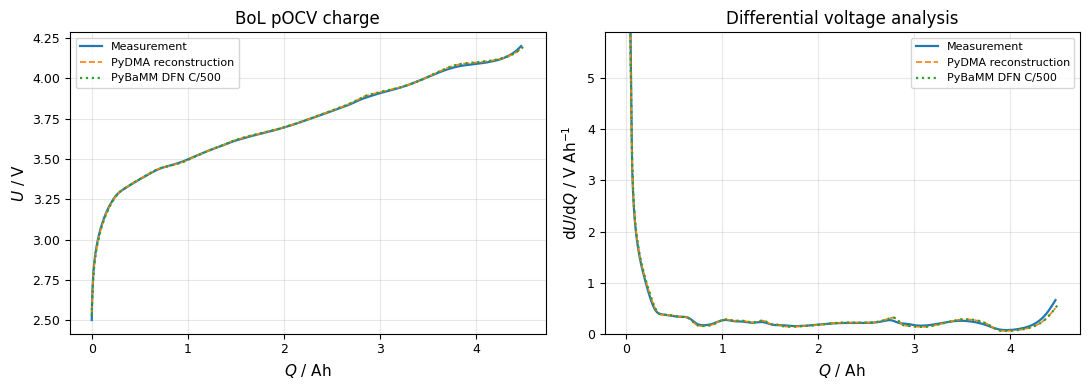

In [8]:
# PyDMA reconstruction lives on a normalised SOC [0,1] grid; convert to Ah
# to overlay on the measurement and the DFN trace.
q_recon    = result.soc_reconstructed * Q_BoL_Ah
volt_recon = result.ocv_reconstructed

# Common dV/dQ operator on all three traces.
dva_kw = dict(n_points=1000, smooth_window=30)
q_meas_dva,  _, dva_meas  = calculate_dva(q_meas,  volt_meas, **dva_kw)
q_recon_dva, _, dva_recon = calculate_dva(q_recon, volt_recon, **dva_kw)
q_sim_dva,   _, dva_sim   = calculate_dva(cap_sim, V_sim,     **dva_kw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(q_meas,  volt_meas,  "-",  color="tab:blue",   lw=1.6, label="Measurement")
ax.plot(q_recon, volt_recon, "--", color="tab:orange", lw=1.2, label="PyDMA reconstruction")
ax.plot(cap_sim, V_sim,      ":",  color="tab:green",  lw=1.6, label="PyBaMM DFN C/500")
ax.set_xlabel(r"$Q$ / Ah")
ax.set_ylabel(r"$U$ / V")
ax.set_title("BoL pOCV charge")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(q_meas_dva,  dva_meas,  "-",  color="tab:blue",   lw=1.6, label="Measurement")
ax.plot(q_recon_dva, dva_recon, "--", color="tab:orange", lw=1.2, label="PyDMA reconstruction")
ax.plot(q_sim_dva,   dva_sim,   ":",  color="tab:green",  lw=1.6, label="PyBaMM DFN C/500")
ax.set_xlabel(r"$Q$ / Ah")
ax.set_ylabel(r"$\mathrm{d}U/\mathrm{d}Q$ / V Ah$^{-1}$")
ax.set_title("Differential voltage analysis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, np.nanpercentile(dva_meas, 99))

plt.tight_layout()
plt.show()


## 9. Wrap-up

**PyDMA helpers that did the heavy lifting in this notebook:**

- `pydma.load_ocp` — half-cell CSV loader (cathode)
- `pydma.generate_si_curve` — Si OCP synthesis from Gr + blend
- `pydma.BlendElectrode` — anode model + `get_blend_curve`
- `pydma.DMAAnalyzer` / `DMAConfig` — the actual fit
- `pydma.CellGeometry` + `pydma.derive_balancing_from_result`
- `ElectrodeBalancing.pybamm_overrides` — the four
  `c_max / c_init` PyBaMM keys in one call
- `pydma.calculate_dva` — uniform DVA operator across all three
  traces in §8

If you have not run a PyDMA fit yet, start with
`getting_started.ipynb` — it walks through the analysis at
longer length.

**Aged check-ups** follow exactly the same recipe: pass the aged
CU's `voltage_anchored_windows` and scale `geom.eps_s_*` by
`(1 - lam_*)` from `result.degradation_modes`. PyBaMM then derives
the updated `Q_Li` automatically from the seeded `c_init`. No code
here — this is left as a one-line stub.
